In [1]:
import pandas as pd

df = pd.read_csv('owid-co2-final-cleaned.csv')
print(df.shape)
df.head()

(6777, 15)


,country,year,iso_code,land_use_change_co2_signed_log,total_ghg_log,population_log,temperature_change_from_ghg_sqrt,nitrous_oxide_log,methane_log,temperature_change_from_ch4_cbrt,co2_per_capita_log,share_of_temperature_change_from_ghg_sqrt,ghg_per_capita_log,methane_per_capita_log,nitrous_oxide_per_capita_sqrt
0,Afghanistan,1990,AFG,0.158712,2.675458,16.304215,0.031623,1.301825,2.045626,0.0,0.155293,0.300000,0.752359,0.444045,0.471169
1,Afghanistan,1991,AFG,0.024693,2.688596,16.320128,0.031623,1.321756,2.082188,0.0,0.144966,0.296648,0.751416,0.453620,0.474342
2,Afghanistan,1992,AFG,-0.978702,2.529163,16.401693,0.031623,1.305084,2.092851,0.0,0.106160,0.294958,0.625404,0.428530,0.449444
3,Afghanistan,1993,AFG,-1.623538,2.438339,16.519765,0.031623,1.315604,2.104012,0.0,0.095310,0.291548,0.530628,0.393393,0.426615
4,Afghanistan,1994,AFG,-1.485913,2.483239,16.603653,0.031623,1.273965,2.138771,0.0,0.085260,0.289828,0.516410,0.379121,0.397492


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model   import LinearRegression, Ridge
from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics        import r2_score, mean_squared_error
from sklearn.preprocessing  import StandardScaler
from xgboost                import XGBRegressor
import numpy as np

In [3]:
TARGET   = 'co2_per_capita_log'
DROP     = ['country', 'iso_code', TARGET]
FEATURES = [c for c in df.columns if c not in DROP]

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {FEATURES}')

Features: ['year', 'land_use_change_co2_signed_log', 'total_ghg_log', 'population_log', 'temperature_change_from_ghg_sqrt', 'nitrous_oxide_log', 'methane_log', 'temperature_change_from_ch4_cbrt', 'share_of_temperature_change_from_ghg_sqrt', 'ghg_per_capita_log', 'methane_per_capita_log', 'nitrous_oxide_per_capita_sqrt']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5421, 12) | Test: (1356, 12)


In [5]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

r2   = r2_score(y_test, lr.predict(X_test_sc))
rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test_sc)))
cv   = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='r2')

print(f'R²  : {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'CV  : {cv.mean():.4f} ± {cv.std():.4f}')

R²  : 0.7733
RMSE: 0.4053
CV  : 0.7638 ± 0.0128


In [6]:
ridge = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='r2', n_jobs=-1
)
ridge.fit(X_train_sc, y_train)

r2   = r2_score(y_test, ridge.predict(X_test_sc))
rmse = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_sc)))

print(f'Best alpha: {ridge.best_params_["alpha"]}')
print(f'R²  : {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

Best alpha: 1
R²  : 0.7732
RMSE: 0.4053


In [7]:
rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth'   : [None, 10, 20],
    },
    cv=5, scoring='r2', n_jobs=-1
)
rf.fit(X_train, y_train)

r2   = r2_score(y_test, rf.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))

print(f'Best params: {rf.best_params_}')
print(f'R²  : {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

Best params: {'max_depth': 20, 'n_estimators': 200}
R²  : 0.9850
RMSE: 0.1043


In [8]:
gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid={
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5],
    },
    cv=5, scoring='r2', n_jobs=-1
)
gb.fit(X_train, y_train)

r2   = r2_score(y_test, gb.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, gb.predict(X_test)))

print(f'Best params: {gb.best_params_}')
print(f'R²  : {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
R²  : 0.9838
RMSE: 0.1084


In [9]:
xgb = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid={
        'n_estimators' : [100, 200],
        'max_depth'    : [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
    },
    cv=5, scoring='r2', n_jobs=-1
)
xgb.fit(X_train, y_train)

r2   = r2_score(y_test, xgb.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, xgb.predict(X_test)))

print(f'Best params: {xgb.best_params_}')
print(f'R²  : {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
R²  : 0.9859
RMSE: 0.1009


In [10]:
results = pd.Series({
    'Linear Regression' : r2_score(y_test, lr.predict(X_test_sc)),
    'Ridge'             : r2_score(y_test, ridge.predict(X_test_sc)),
    'Random Forest'     : r2_score(y_test, rf.predict(X_test)),
    'Gradient Boosting' : r2_score(y_test, gb.predict(X_test)),
    'XGBoost'           : r2_score(y_test, xgb.predict(X_test)),
}).sort_values(ascending=False)

print(results.to_string())

XGBoost              0.985935
Random Forest        0.984995
Gradient Boosting    0.983793
Linear Regression    0.773273
Ridge                0.773242


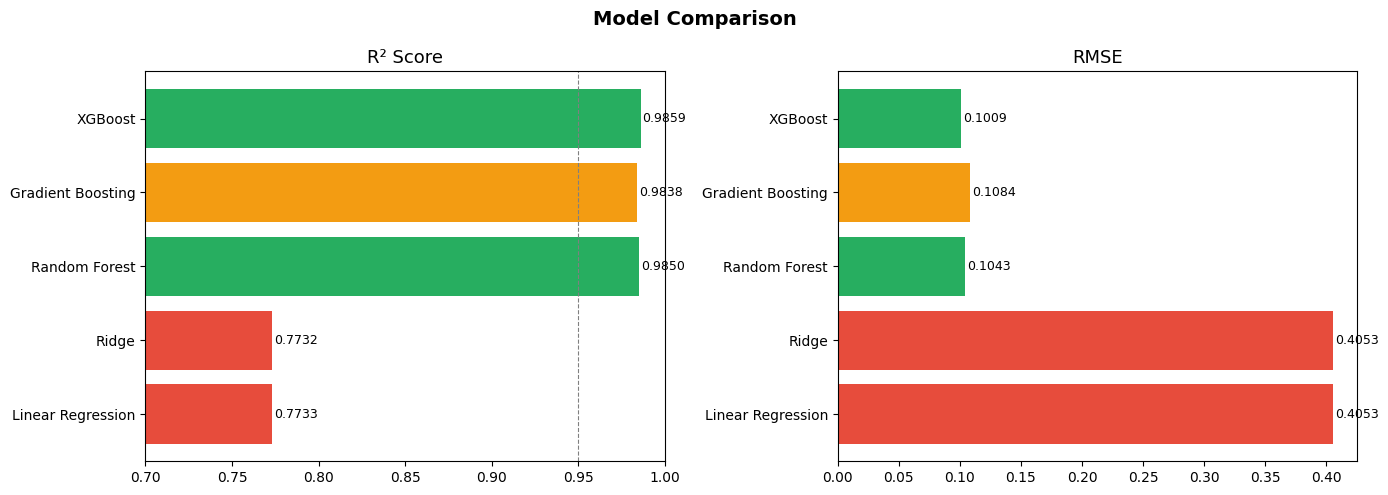

Best model: XGBoost — R² = 0.9859


In [12]:
import matplotlib.pyplot as plt
import numpy as np

models_names = ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting', 'XGBoost']

r2_scores = [
    r2_score(y_test, lr.predict(X_test_sc)),
    r2_score(y_test, ridge.predict(X_test_sc)),
    r2_score(y_test, rf.predict(X_test)),
    r2_score(y_test, gb.predict(X_test)),
    r2_score(y_test, xgb.predict(X_test)),
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, lr.predict(X_test_sc))),
    np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_sc))),
    np.sqrt(mean_squared_error(y_test, rf.predict(X_test))),
    np.sqrt(mean_squared_error(y_test, gb.predict(X_test))),
    np.sqrt(mean_squared_error(y_test, xgb.predict(X_test))),
]

colors = ['#e74c3c', '#e74c3c', '#27ae60', '#f39c12', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(models_names, r2_scores, color=colors)
axes[0].set_xlim(0.7, 1.0)
axes[0].set_title('R² Score', fontsize=13)
axes[0].axvline(x=0.95, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, r2_scores):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

bars2 = axes[1].barh(models_names, rmse_scores, color=colors)
axes[1].set_title('RMSE', fontsize=13)
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = models_names[r2_scores.index(max(r2_scores))]
print(f'Best model: {best_model} — R² = {max(r2_scores):.4f}')

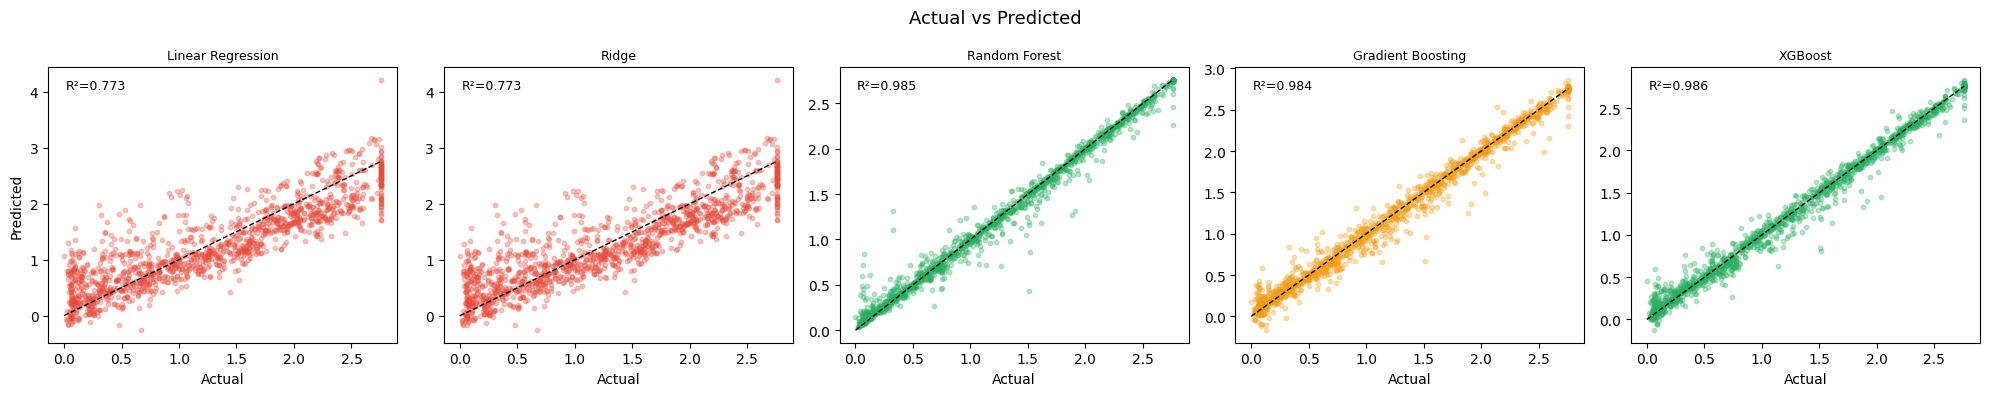

In [13]:
all_preds = [
    lr.predict(X_test_sc),
    ridge.predict(X_test_sc),
    rf.predict(X_test),
    gb.predict(X_test),
    xgb.predict(X_test),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (name, preds) in enumerate(zip(models_names, all_preds)):
    axes[i].scatter(y_test, preds, alpha=0.3, s=10, color=colors[i])
    mn, mx = y_test.min(), y_test.max()
    axes[i].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted') if i == 0 else None
    axes[i].text(0.05, 0.92, f'R²={r2_scores[i]:.3f}',
                 transform=axes[i].transAxes, fontsize=9)

plt.suptitle('Actual vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()